# Single Spectrum Inference

Этот ноутбук показывает inference на одном конкретном спектре через Python API `infer_single_spectrum_file(...)`.

Что делает ноутбук:
- запускает inference для одного файла `center=1500`
- запускает inference для одного файла `center=2900`
- показывает итоговый класс и вероятности
- визуализирует спектр, найденные пики и важные спектральные области
- показывает attribution по спектральной оси

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.append('/home/yaroslav/progs/biohack/deeppick_mephi_2026/ml')

from src.raman_mil.inference import infer_single_spectrum_file

plt.style.use("ggplot")

PROJECT_ROOT = Path('/home/yaroslav/progs/biohack/deeppick_mephi_2026/ml')
SPECTR_DIR = PROJECT_ROOT / "spectr_data"

FILE_1500 = SPECTR_DIR / "spectrum_04_center1500_striatum_left_endo_2Agroup_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place1_3_spec250.txt"
FILE_2900 = SPECTR_DIR / "spectrum_01_center2900_striatum_right_control_2Bgroup_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place3_4_spec025.txt"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FILE_1500 exists:", FILE_1500.exists())
print("FILE_2900 exists:", FILE_2900.exists())

PROJECT_ROOT: /home/yaroslav/progs/biohack/deeppick_mephi_2026/ml
FILE_1500 exists: True
FILE_2900 exists: True


## Helper Functions

Ниже небольшие helper-функции для компактного вывода результатов и визуализации.

In [2]:
def print_prediction_summary(result: dict) -> pd.DataFrame:
    df = pd.DataFrame(
        {
            "class": list(result["class_probs"].keys()),
            "probability": list(result["class_probs"].values()),
        }
    ).sort_values("probability", ascending=False, ignore_index=True)
    print("predicted class:", result["pred_class_name"])
    display(df)
    return df


def plot_inference_result(result: dict, title: str) -> None:
    spectrum = result["visualization"]["spectrum"]
    peaks = result["visualization"]["peaks"]
    regions = result["visualization"]["important_regions"]
    attribution = result["visualization"].get("attribution")

    nrows = 2 if attribution is not None else 1
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(14, 8 if nrows == 2 else 5), sharex=False)
    if nrows == 1:
        axes = [axes]

    ax = axes[0]
    x = np.asarray(spectrum["x"])
    y = np.asarray(spectrum["y"])
    ax.plot(x, y, color="black", linewidth=1.2, label="processed spectrum")

    for region in regions:
        ax.axvspan(region["start_nu"], region["end_nu"], color="tab:red", alpha=0.18)

    if peaks:
        peak_x = [item["peak_nu"] for item in peaks]
        peak_y = [item["intensity"] for item in peaks]
        ax.scatter(peak_x, peak_y, color="tab:blue", s=28, label="peaks", zorder=3)

    ax.set_title(title)
    ax.set_ylabel("Intensity")
    ax.legend(loc="best")

    if attribution is not None:
        ax_attr = axes[1]
        ax_attr.plot(attribution["x"], attribution["y"], color="tab:green", linewidth=1.0)
        ax_attr.axhline(0.0, color="black", linewidth=0.8)
        for region in regions:
            ax_attr.axvspan(region["start_nu"], region["end_nu"], color="tab:red", alpha=0.18)
        ax_attr.set_title("Integrated Gradients attribution")
        ax_attr.set_xlabel("Raman shift")
        ax_attr.set_ylabel("Attribution")
    else:
        ax.set_xlabel("Raman shift")

    plt.tight_layout()
    plt.show()


def show_regions_and_peaks(result: dict) -> None:
    peaks_df = pd.DataFrame(result["visualization"]["peaks"])
    regions_df = pd.DataFrame(result["visualization"]["important_regions"])
    print("Top peaks")
    display(peaks_df.head(10))
    print("Important spectral regions")
    display(regions_df.head(10))

## Inference: center 1500

predicted class: control


,class,probability
0,control,0.367511
1,endo,0.348996
2,exo,0.283493


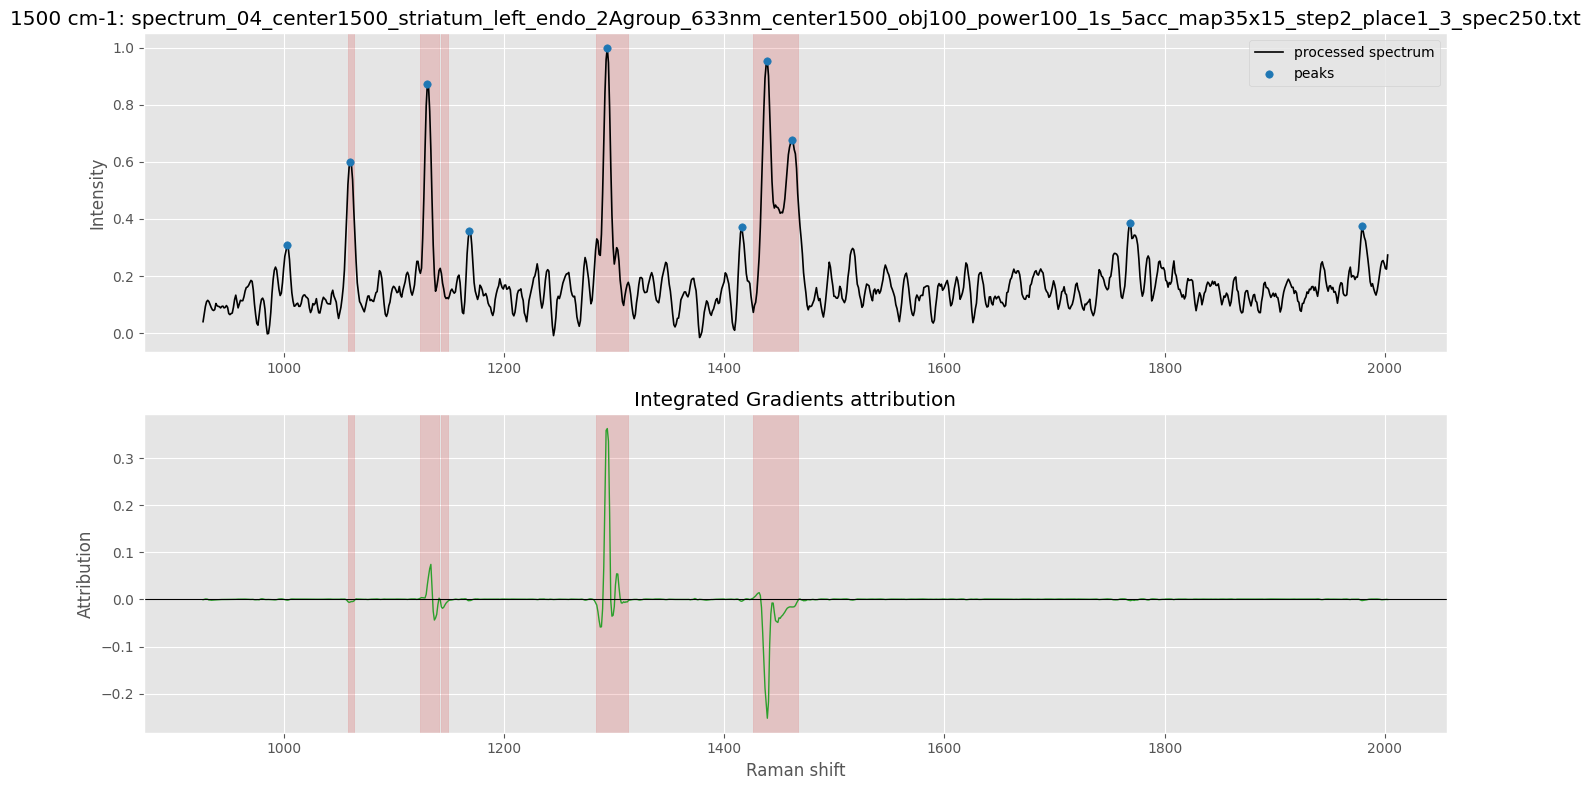

Top peaks


,peak_idx,peak_nu,intensity,prominence
0,346,1293.862793,1.000000,1.008831
1,483,1439.191162,0.954542,0.919334
2,192,1130.500977,0.874361,0.877118
3,126,1060.488770,0.599920,0.541536
4,793,1768.036377,0.385859,0.315196
5,461,1415.853760,0.373515,0.300935
6,228,1168.689453,0.358512,0.290360
7,504,1461.467773,0.677755,0.257752
8,72,1003.206055,0.307340,0.256085
9,992,1979.133789,0.374031,0.240792


Important spectral regions


,start_idx,end_idx,start_nu,end_nu,peak_idx,peak_nu,score_sum,score_max
0,336,364,1283.254883,1312.957031,346,1293.862793,2.050105,0.362847
1,471,509,1426.461670,1466.771729,483,1439.191162,1.828895,0.252106
2,186,202,1124.136230,1141.108887,195,1133.683350,0.425578,0.074481
3,204,210,1143.230469,1149.595215,205,1144.291260,0.078372,0.018743
4,124,129,1058.367188,1063.671143,125,1059.427979,0.028280,0.006256


In [3]:
result_1500 = infer_single_spectrum_file(
    spectrum_path=FILE_1500,
    center=1500,
    device="cpu",
    explain=True,
    ig_steps=32,
)

summary_1500 = print_prediction_summary(result_1500)
plot_inference_result(result_1500, title=f"1500 cm-1: {FILE_1500.name}")
show_regions_and_peaks(result_1500)

## Inference: center 2900

predicted class: control


,class,probability
0,control,0.402150
1,endo,0.319258
2,exo,0.278592


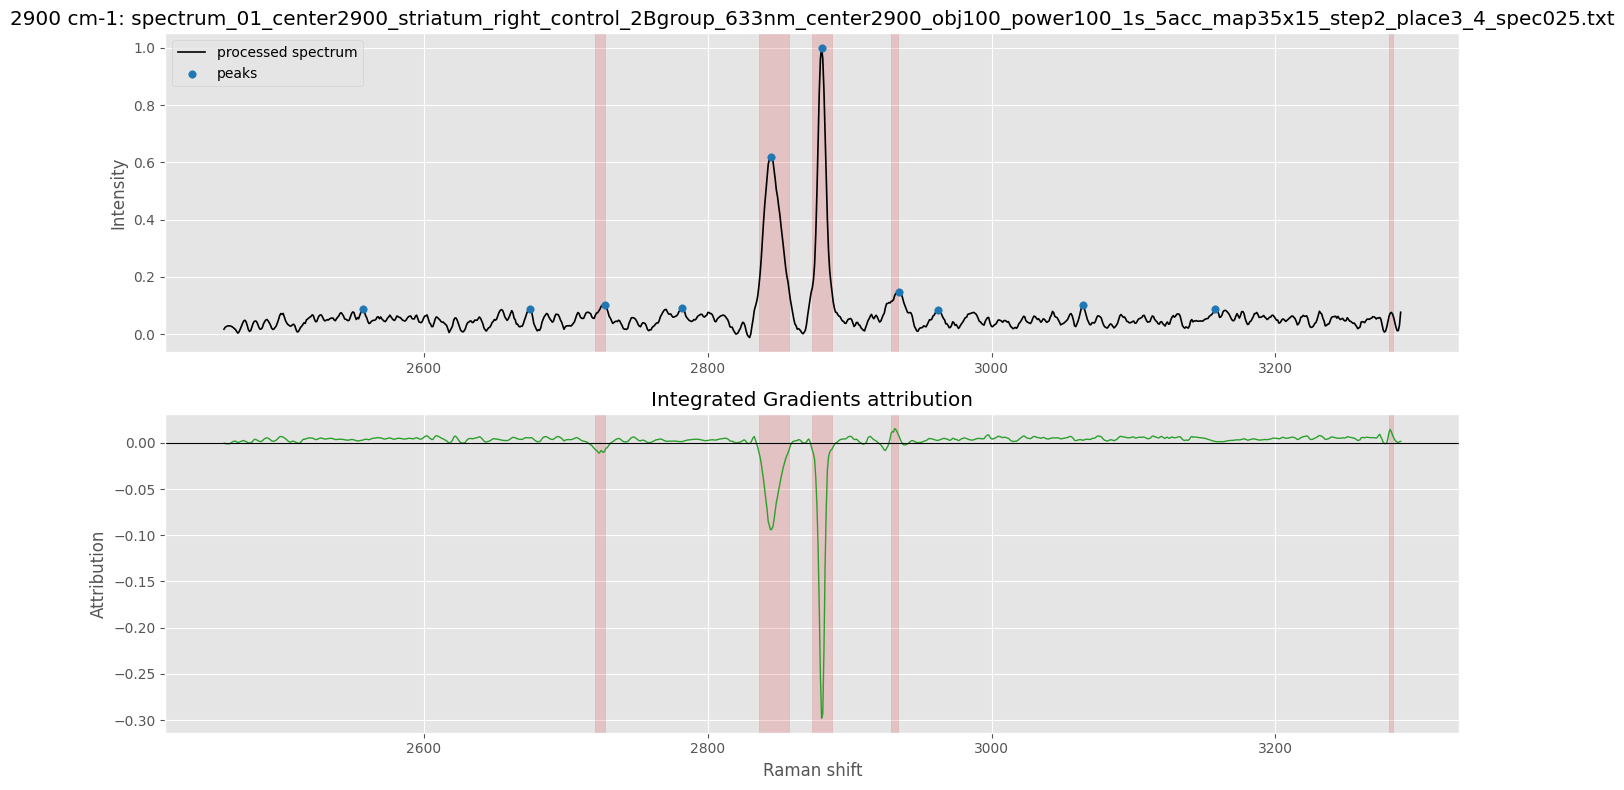

Top peaks


,peak_idx,peak_nu,intensity,prominence
0,515,2880.210449,1.000000,0.993192
1,471,2844.224121,0.620113,0.619042
2,582,2935.007812,0.145534,0.134616
3,328,2727.268555,0.103176,0.099890
4,740,3064.231445,0.102143,0.092572
5,120,2557.151367,0.087217,0.082081
6,395,2782.065918,0.089647,0.077871
7,264,2674.924805,0.088648,0.077683
8,615,2961.997559,0.084864,0.066355
9,854,3157.468750,0.085991,0.065454


Important spectral regions


,start_idx,end_idx,start_nu,end_nu,peak_idx,peak_nu,score_sum,score_max
0,507,524,2873.667480,2887.571289,515,2880.210449,1.783836,0.298016
1,461,487,2836.045410,2857.310059,471,2844.224121,1.300797,0.094222
2,575,581,2929.282715,2934.189941,578,2931.736328,0.085189,0.015444
3,320,328,2720.725586,2727.268555,323,2723.179199,0.083591,0.011160
4,1004,1007,3280.149414,3282.603027,1005,3280.967285,0.046317,0.014443


In [4]:
result_2900 = infer_single_spectrum_file(
    spectrum_path=FILE_2900,
    center=2900,
    device="cpu",
    explain=True,
    ig_steps=32,
)

summary_2900 = print_prediction_summary(result_2900)
plot_inference_result(result_2900, title=f"2900 cm-1: {FILE_2900.name}")
show_regions_and_peaks(result_2900)

## Compact Frontend Payload

Ниже пример, какой минимальный payload удобно отдавать на frontend: класс, вероятности, спектр, пики и важные области.

In [5]:
frontend_payload_1500 = {
    "pred_class_id": result_1500["pred_class_id"],
    "pred_class_name": result_1500["pred_class_name"],
    "class_probs": result_1500["class_probs"],
    "visualization": result_1500["visualization"],
}

frontend_payload_2900 = {
    "pred_class_id": result_2900["pred_class_id"],
    "pred_class_name": result_2900["pred_class_name"],
    "class_probs": result_2900["class_probs"],
    "visualization": result_2900["visualization"],
}

print("1500 payload keys:", frontend_payload_1500.keys())
print("2900 payload keys:", frontend_payload_2900.keys())
print("1500 predicted class:", frontend_payload_1500["pred_class_name"])
print("2900 predicted class:", frontend_payload_2900["pred_class_name"])

1500 payload keys: dict_keys(['pred_class_id', 'pred_class_name', 'class_probs', 'visualization'])
2900 payload keys: dict_keys(['pred_class_id', 'pred_class_name', 'class_probs', 'visualization'])
1500 predicted class: control
2900 predicted class: control
